# 02 — Feature Engineering

Carga el dataset generado por `fetch_nrel.py` (PVWatts API) y prepara las features para el modelo.

- **Fuente**: PVWatts v8 API con `dataset=intl` — cubre Chile
- **Target real**: `ac_annual` calculado con física de PVWatts, calibrado con datos reales de la API
- **Features**: parámetros de instalación + irradiancia real del sitio

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(exist_ok=True)

## 1. Cargar dataset de entrenamiento

In [2]:
df = pd.read_csv(DATA_RAW / 'pvwatts_chile_training.csv')
print(df.shape)
df.head()

(3000, 10)


,city,region,latitude,longitude,system_size_kw,tilt,azimuth,losses,solrad_annual,ac_annual
0,Antofagasta,Antofagasta,-23.65,-70.4,12.06,35.1,321.7,15.3,6.260674,19818.9
1,Antofagasta,Antofagasta,-23.65,-70.4,7.71,24.4,5.7,18.8,6.260674,13086.5
2,Antofagasta,Antofagasta,-23.65,-70.4,13.16,28.3,18.4,17.6,6.260674,22354.7
3,Antofagasta,Antofagasta,-23.65,-70.4,11.07,23.2,9.4,17.1,6.260674,19158.9
4,Antofagasta,Antofagasta,-23.65,-70.4,3.22,22.3,15.8,11.8,6.260674,5903.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            3000 non-null   object 
 1   region          3000 non-null   object 
 2   latitude        3000 non-null   float64
 3   longitude       3000 non-null   float64
 4   system_size_kw  3000 non-null   float64
 5   tilt            3000 non-null   float64
 6   azimuth         3000 non-null   float64
 7   losses          3000 non-null   float64
 8   solrad_annual   3000 non-null   float64
 9   ac_annual       3000 non-null   float64
dtypes: float64(8), object(2)
memory usage: 234.5+ KB


In [4]:
df.describe().round(2)

,latitude,longitude,system_size_kw,tilt,azimuth,losses,solrad_annual,ac_annual
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,-36.66,-71.40,8.46,36.63,180.89,15.02,5.06,11701.22
std,8.78,1.03,3.73,11.94,160.62,2.89,0.70,5415.91
min,-53.16,-73.05,2.00,0.00,0.00,10.00,3.93,1992.00
25%,-38.74,-72.60,5.22,28.40,17.20,12.50,4.81,7075.70
50%,-35.50,-70.82,8.51,36.10,288.30,15.05,5.05,11576.20
75%,-33.45,-70.67,11.70,44.30,343.40,17.50,5.28,15925.80
max,-23.65,-70.40,15.00,70.00,360.00,20.00,6.26,28038.20


## 2. Features derivadas

In [5]:
# En Chile el ángulo óptimo ≈ latitud absoluta (paneles al norte)
df['tilt_deviation'] = df['tilt'] - df['latitude'].abs()

# Desviación del azimuth desde el norte (0=óptimo en Chile)
df['azimuth_deviation'] = ((df['azimuth'] + 180) % 360) - 180  # rango -180 a 180

print(df[['tilt_deviation', 'azimuth_deviation']].describe().round(2))

       tilt_deviation  azimuth_deviation
count         3000.00            3000.00
mean            -0.03               0.05
std              7.99              25.29
min            -28.24             -81.60
25%             -5.25             -16.70
50%             -0.04              -0.10
75%              5.39              16.90
max             25.45              85.90


## 3. Producción por ciudad

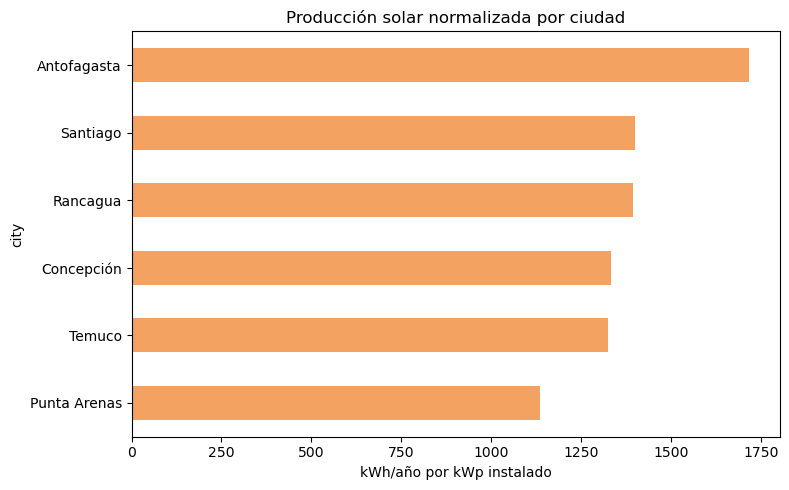

In [6]:
# Producción normalizada por kWp para comparar ciudades
df['kwh_per_kwp'] = df['ac_annual'] / df['system_size_kw']

city_avg = df.groupby('city')['kwh_per_kwp'].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
city_avg.plot.barh(ax=ax, color='#f4a261')
ax.set_xlabel('kWh/año por kWp instalado')
ax.set_title('Producción solar normalizada por ciudad')
plt.tight_layout()

## 4. Relación tilt vs producción

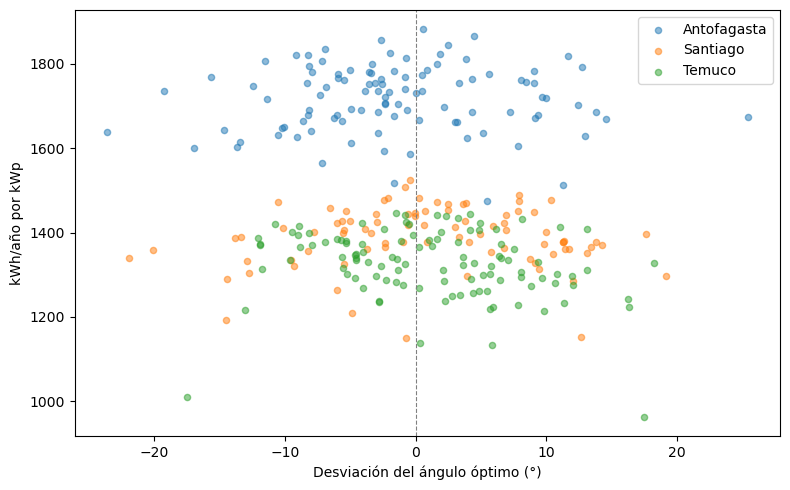

In [7]:
sample = df[df['city'].isin(['Santiago', 'Antofagasta', 'Temuco'])].sample(300, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
for city, grp in sample.groupby('city'):
    ax.scatter(grp['tilt_deviation'], grp['kwh_per_kwp'], label=city, alpha=0.5, s=20)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Desviación del ángulo óptimo (°)')
ax.set_ylabel('kWh/año por kWp')
ax.legend()
plt.tight_layout()

## 5. Outlier check y exportar

In [8]:
z = (df['ac_annual'] - df['ac_annual'].mean()) / df['ac_annual'].std()
outliers = (z.abs() > 4).sum()
print(f'Outliers (>4σ): {outliers}')
df = df[z.abs() <= 4].reset_index(drop=True)
print(f'Dataset final: {df.shape}')

Outliers (>4σ): 0
Dataset final: (3000, 13)


In [9]:
FEATURES = [
    'system_size_kw', 'tilt', 'azimuth', 'losses',
    'tilt_deviation', 'azimuth_deviation',
    'latitude', 'solrad_annual',
]
TARGET = 'ac_annual'

df_model = df[FEATURES + [TARGET, 'city', 'region']]
df_model.to_csv(DATA_PROC / 'solar_chile_model.csv', index=False)
print(f'Guardado: {df_model.shape}')
df_model[FEATURES + [TARGET]].describe().round(1)

Guardado: (3000, 11)


,system_size_kw,tilt,azimuth,losses,tilt_deviation,azimuth_deviation,latitude,solrad_annual,ac_annual
count,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0,3000.0
mean,8.5,36.6,180.9,15.0,-0.0,0.0,-36.7,5.1,11701.2
std,3.7,11.9,160.6,2.9,8.0,25.3,8.8,0.7,5415.9
min,2.0,0.0,0.0,10.0,-28.2,-81.6,-53.2,3.9,1992.0
25%,5.2,28.4,17.2,12.5,-5.3,-16.7,-38.7,4.8,7075.7
50%,8.5,36.1,288.3,15.0,-0.0,-0.1,-35.5,5.0,11576.2
75%,11.7,44.3,343.4,17.5,5.4,16.9,-33.4,5.3,15925.8
max,15.0,70.0,360.0,20.0,25.5,85.9,-23.6,6.3,28038.2
